In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import numpy as np
import feos
import si_units as si
import matplotlib.pyplot as plt
import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=492270542833e46609d619ae3f944b2b0f722b5d97893d0c8060893f51a564a7
  Stored in directory: /tmp/pip-ephem-wheel-cache-u0_q4a2c/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

In [3]:
params          = TC.PARAMETERS(COMPONENT_NAMES)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(params)
feed_si         = FEED_Z * si.MOL
Tc_si, Pc_si    = TC.VLECalculator.compute_critical_point(eos, FEED_Z, T_guess=300.0)
Tc_K            = Tc_si / si.KELVIN
Pc_bar          = Pc_si / si.BAR
T_vals          = np.linspace(200.0, Tc_K , 500)
T_bub, P_bub    = TC.VLECalculator.compute_bubble_curve(eos, T_vals, feed_si, verbose=False)
T_dew, P_dew    = TC.VLECalculator.compute_dew_curve(eos, T_vals, feed_si, verbose=False)

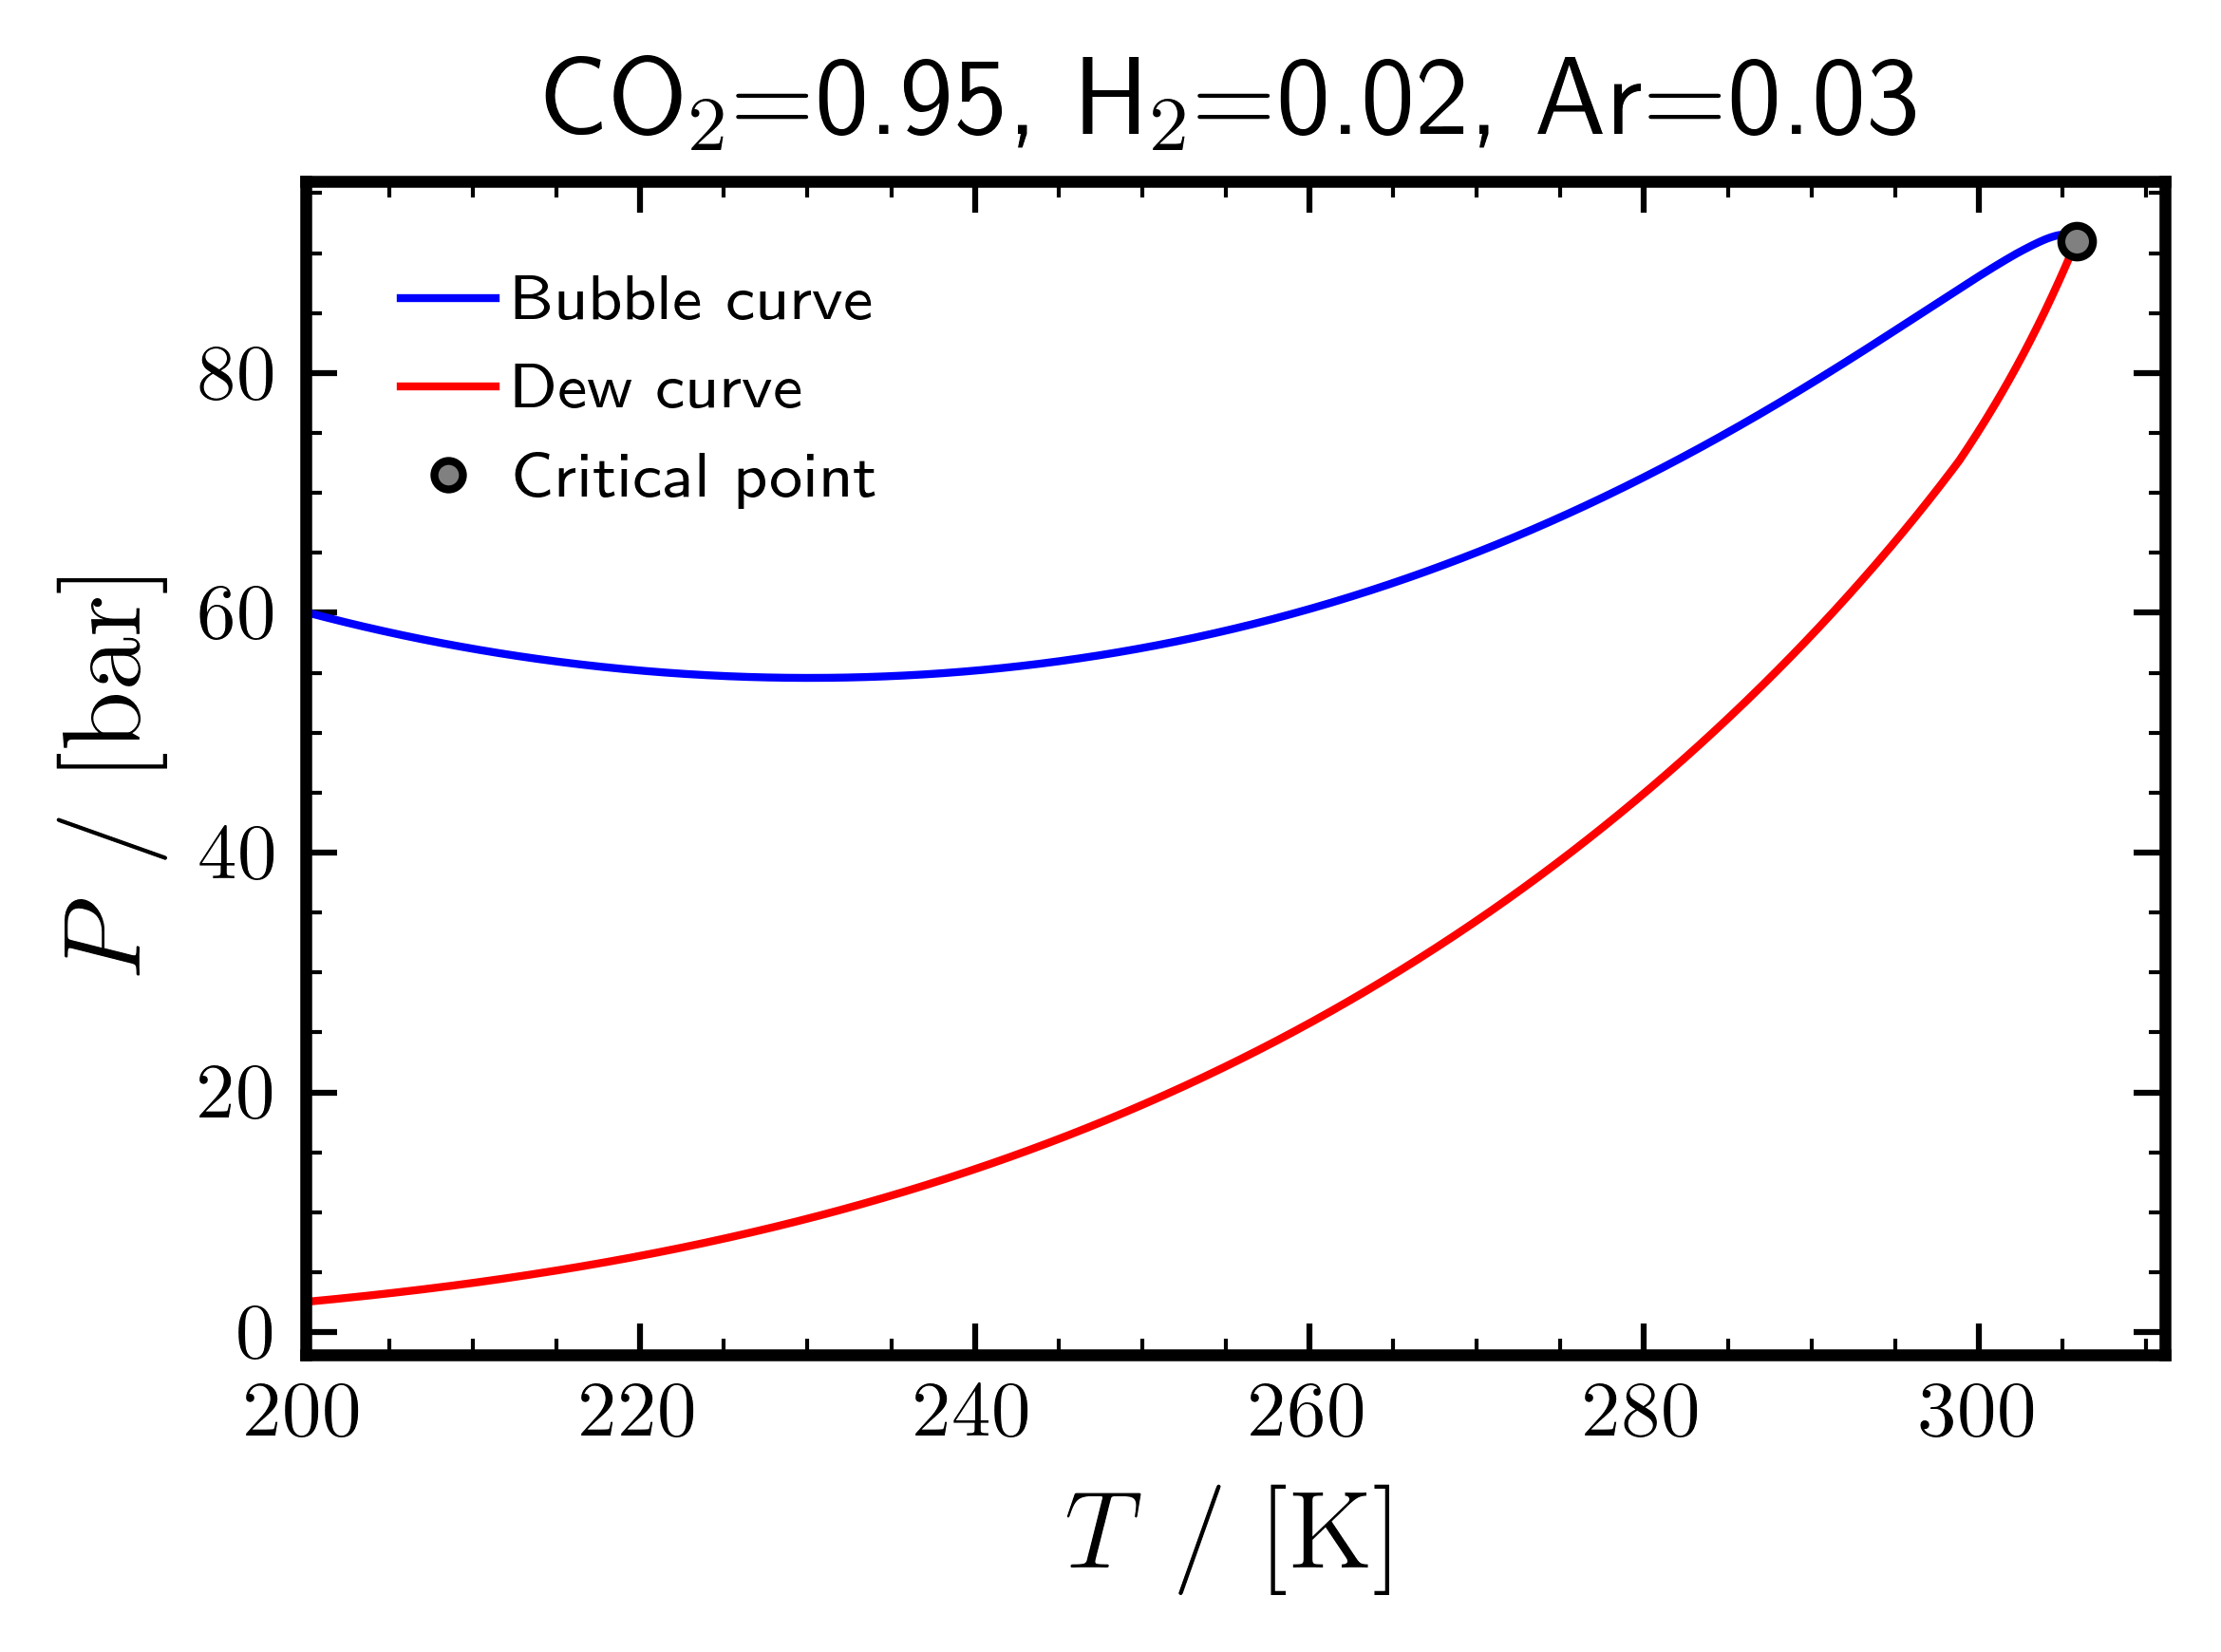

In [4]:
# Build PT_results dict in the format expected by PlottingEngine
feed_key = "feed_0"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew": [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K": Tc_K,
        "PC_bar": Pc_bar,
        "z": FEED_Z,
    }
}

# Plot using PlottingEngine
fig, ax = TC.PlottingEngine.plot_phase_diagram(PT_results, feed_key, params)
plt.show()

In [5]:
# ----------------------------------------------
# Compute PT colormap data with Parachor method
# ---------------------------------------------

model = SEC.semi_emperical_correlations()

# Method 1: Automatic parachor number recomputation at each temperature
data_parachor = model.compute_PT_colormap_data(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    n_T=30,
    n_P=30,
    recompute_parachor=True)

# Method 2: Fixed parachor numbers
T_ref           = 250.0
PARACHOR_FIXED  = model.batch_parachor_numbers(COMPONENT_NAMES, T_ref, n_exp=3.87, verbose=True)

data_parachor_fixed      = model.compute_PT_colormap_data(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    parachor_numbers=PARACHOR_FIXED,   # use fixed values
    recompute_parachor=False,          # disable recomputation
    n_exp=3.87,
    n_T=30,
    n_P=30)

# -----------------------------------------
# WSD method for comparison
# -----------------------------------------
data_wsd = model.compute_PT_colormap_data(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=True,
    n_T=30,
    n_P=30,)

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:179: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=297.6612503604664 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:179: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.8954170538343 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(


carbon dioxide: Parachor = 77.5437
hydrogen: T_K=250.00 > Tc=65.50, using T_ref=58.95 K -> Parachor = 34.0524
argon: T_K=250.00 > Tc=150.29, using T_ref=135.27 K -> Parachor = 56.5531


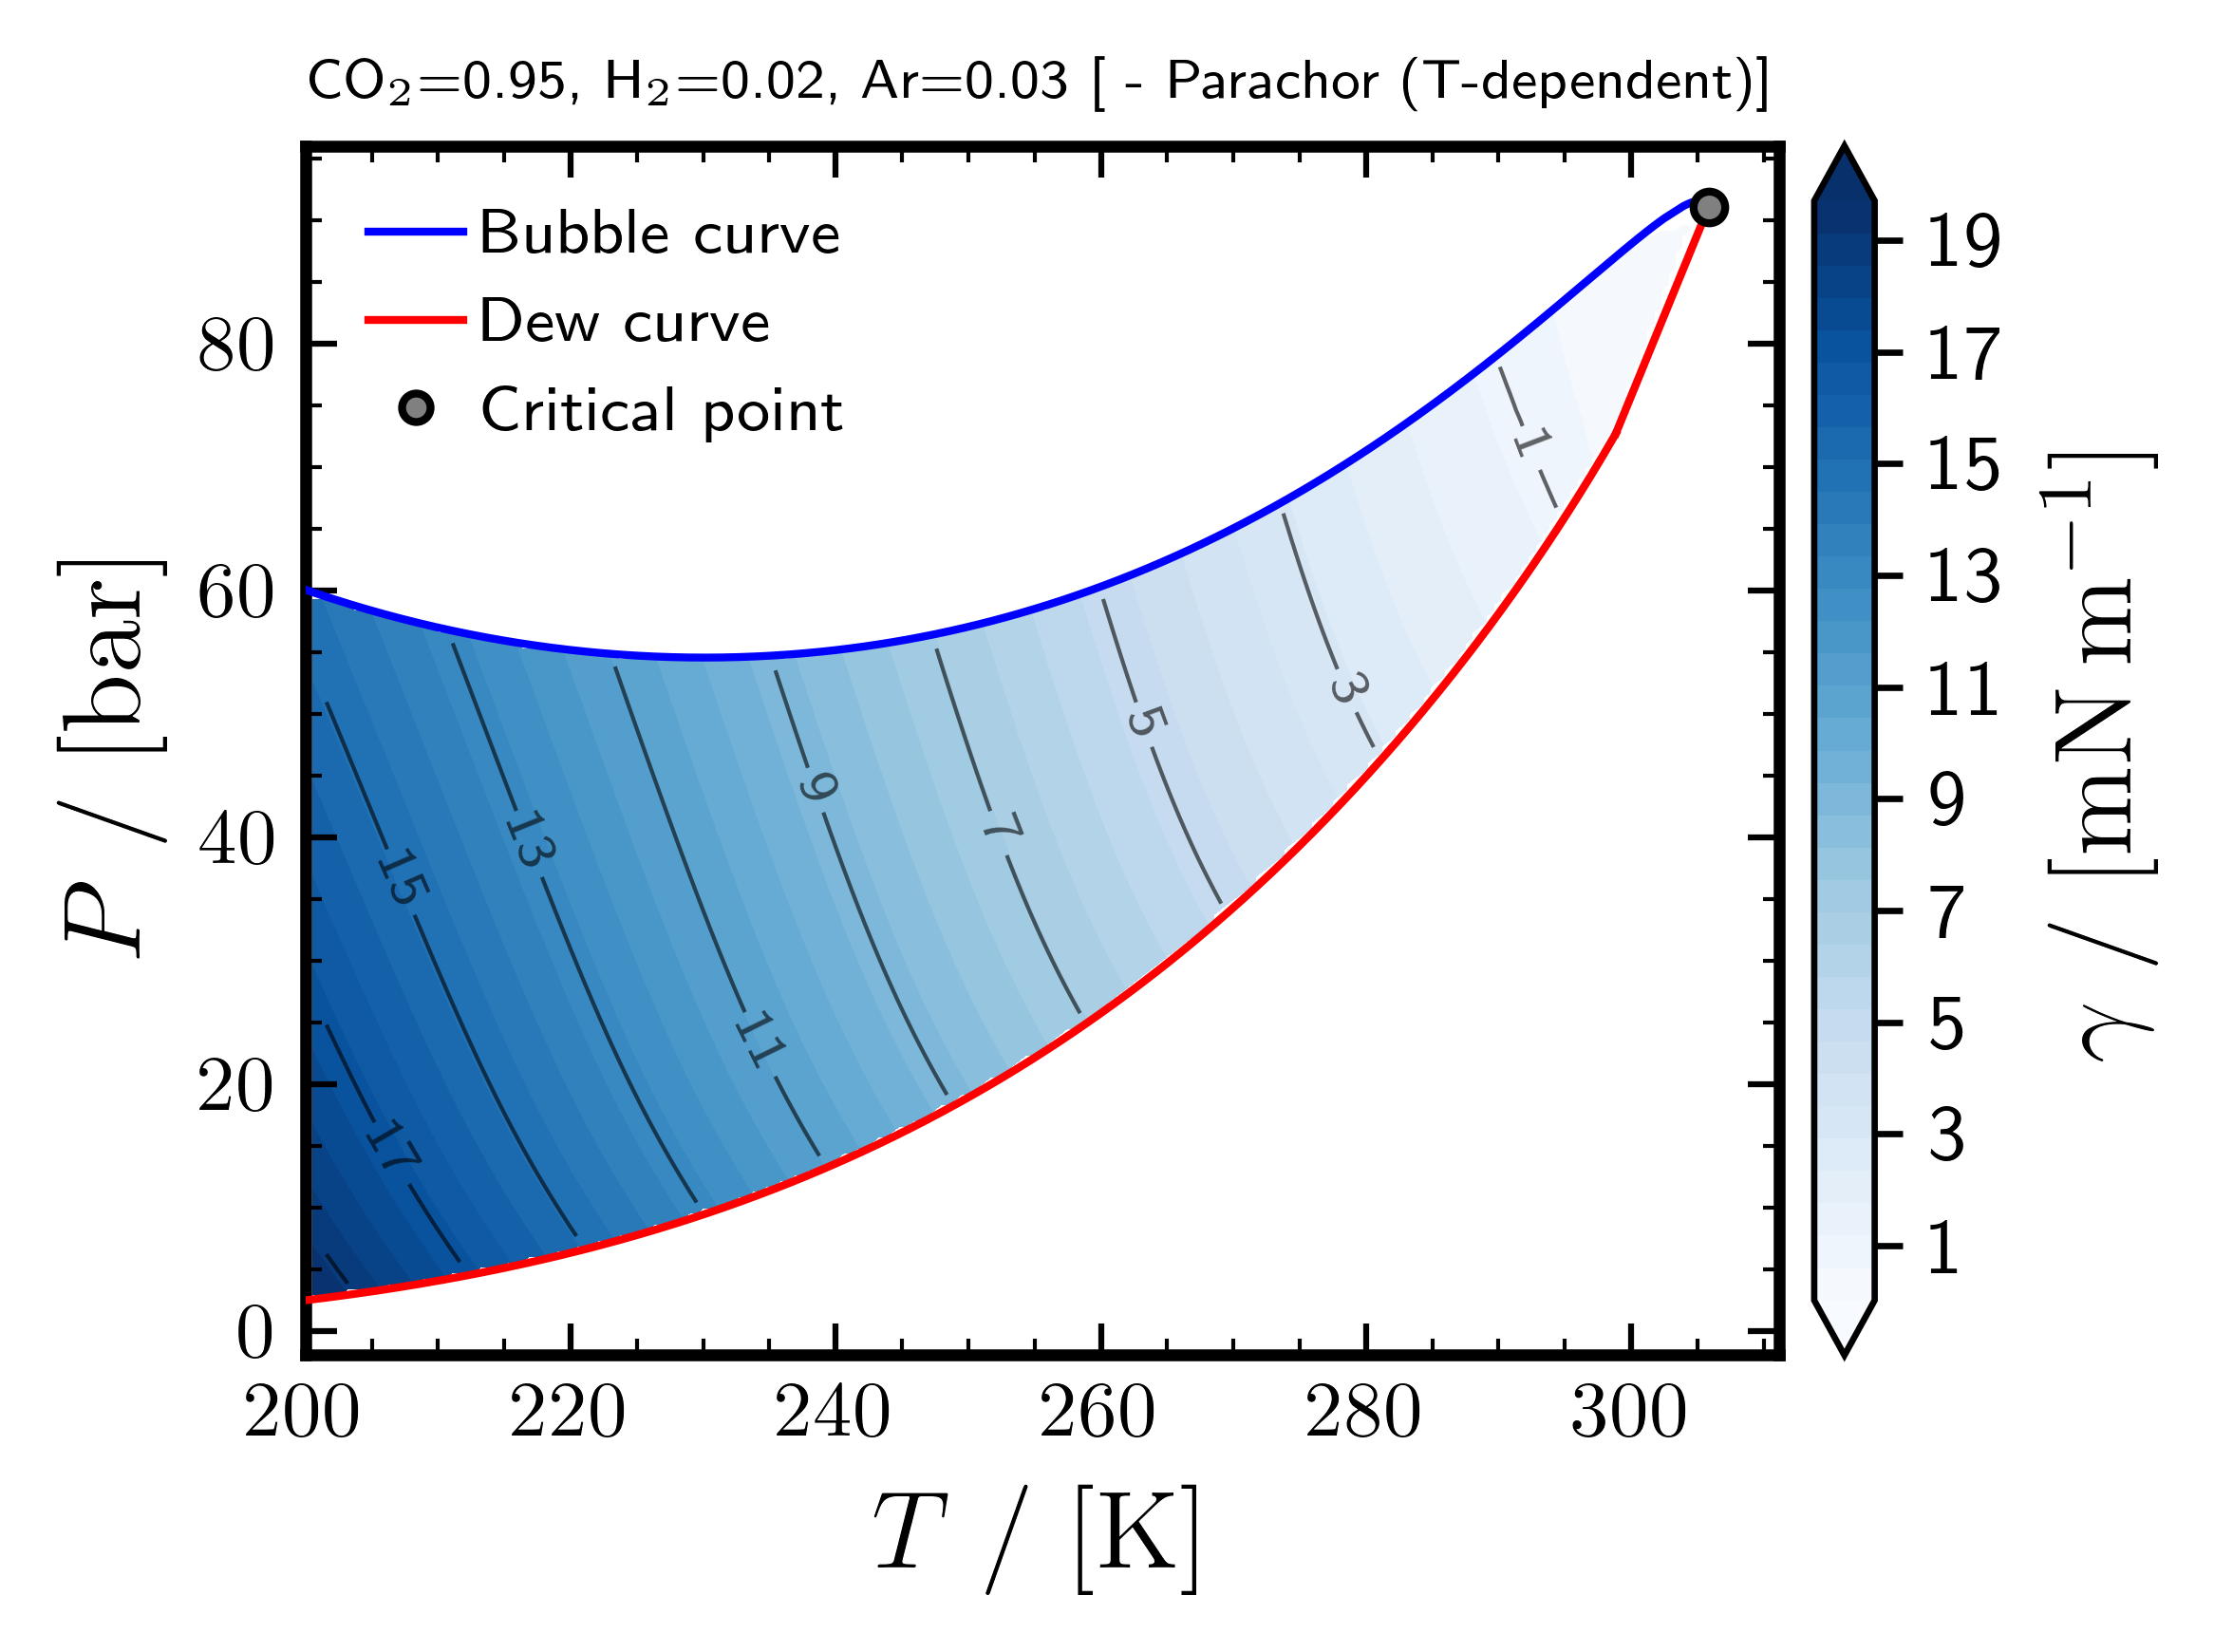

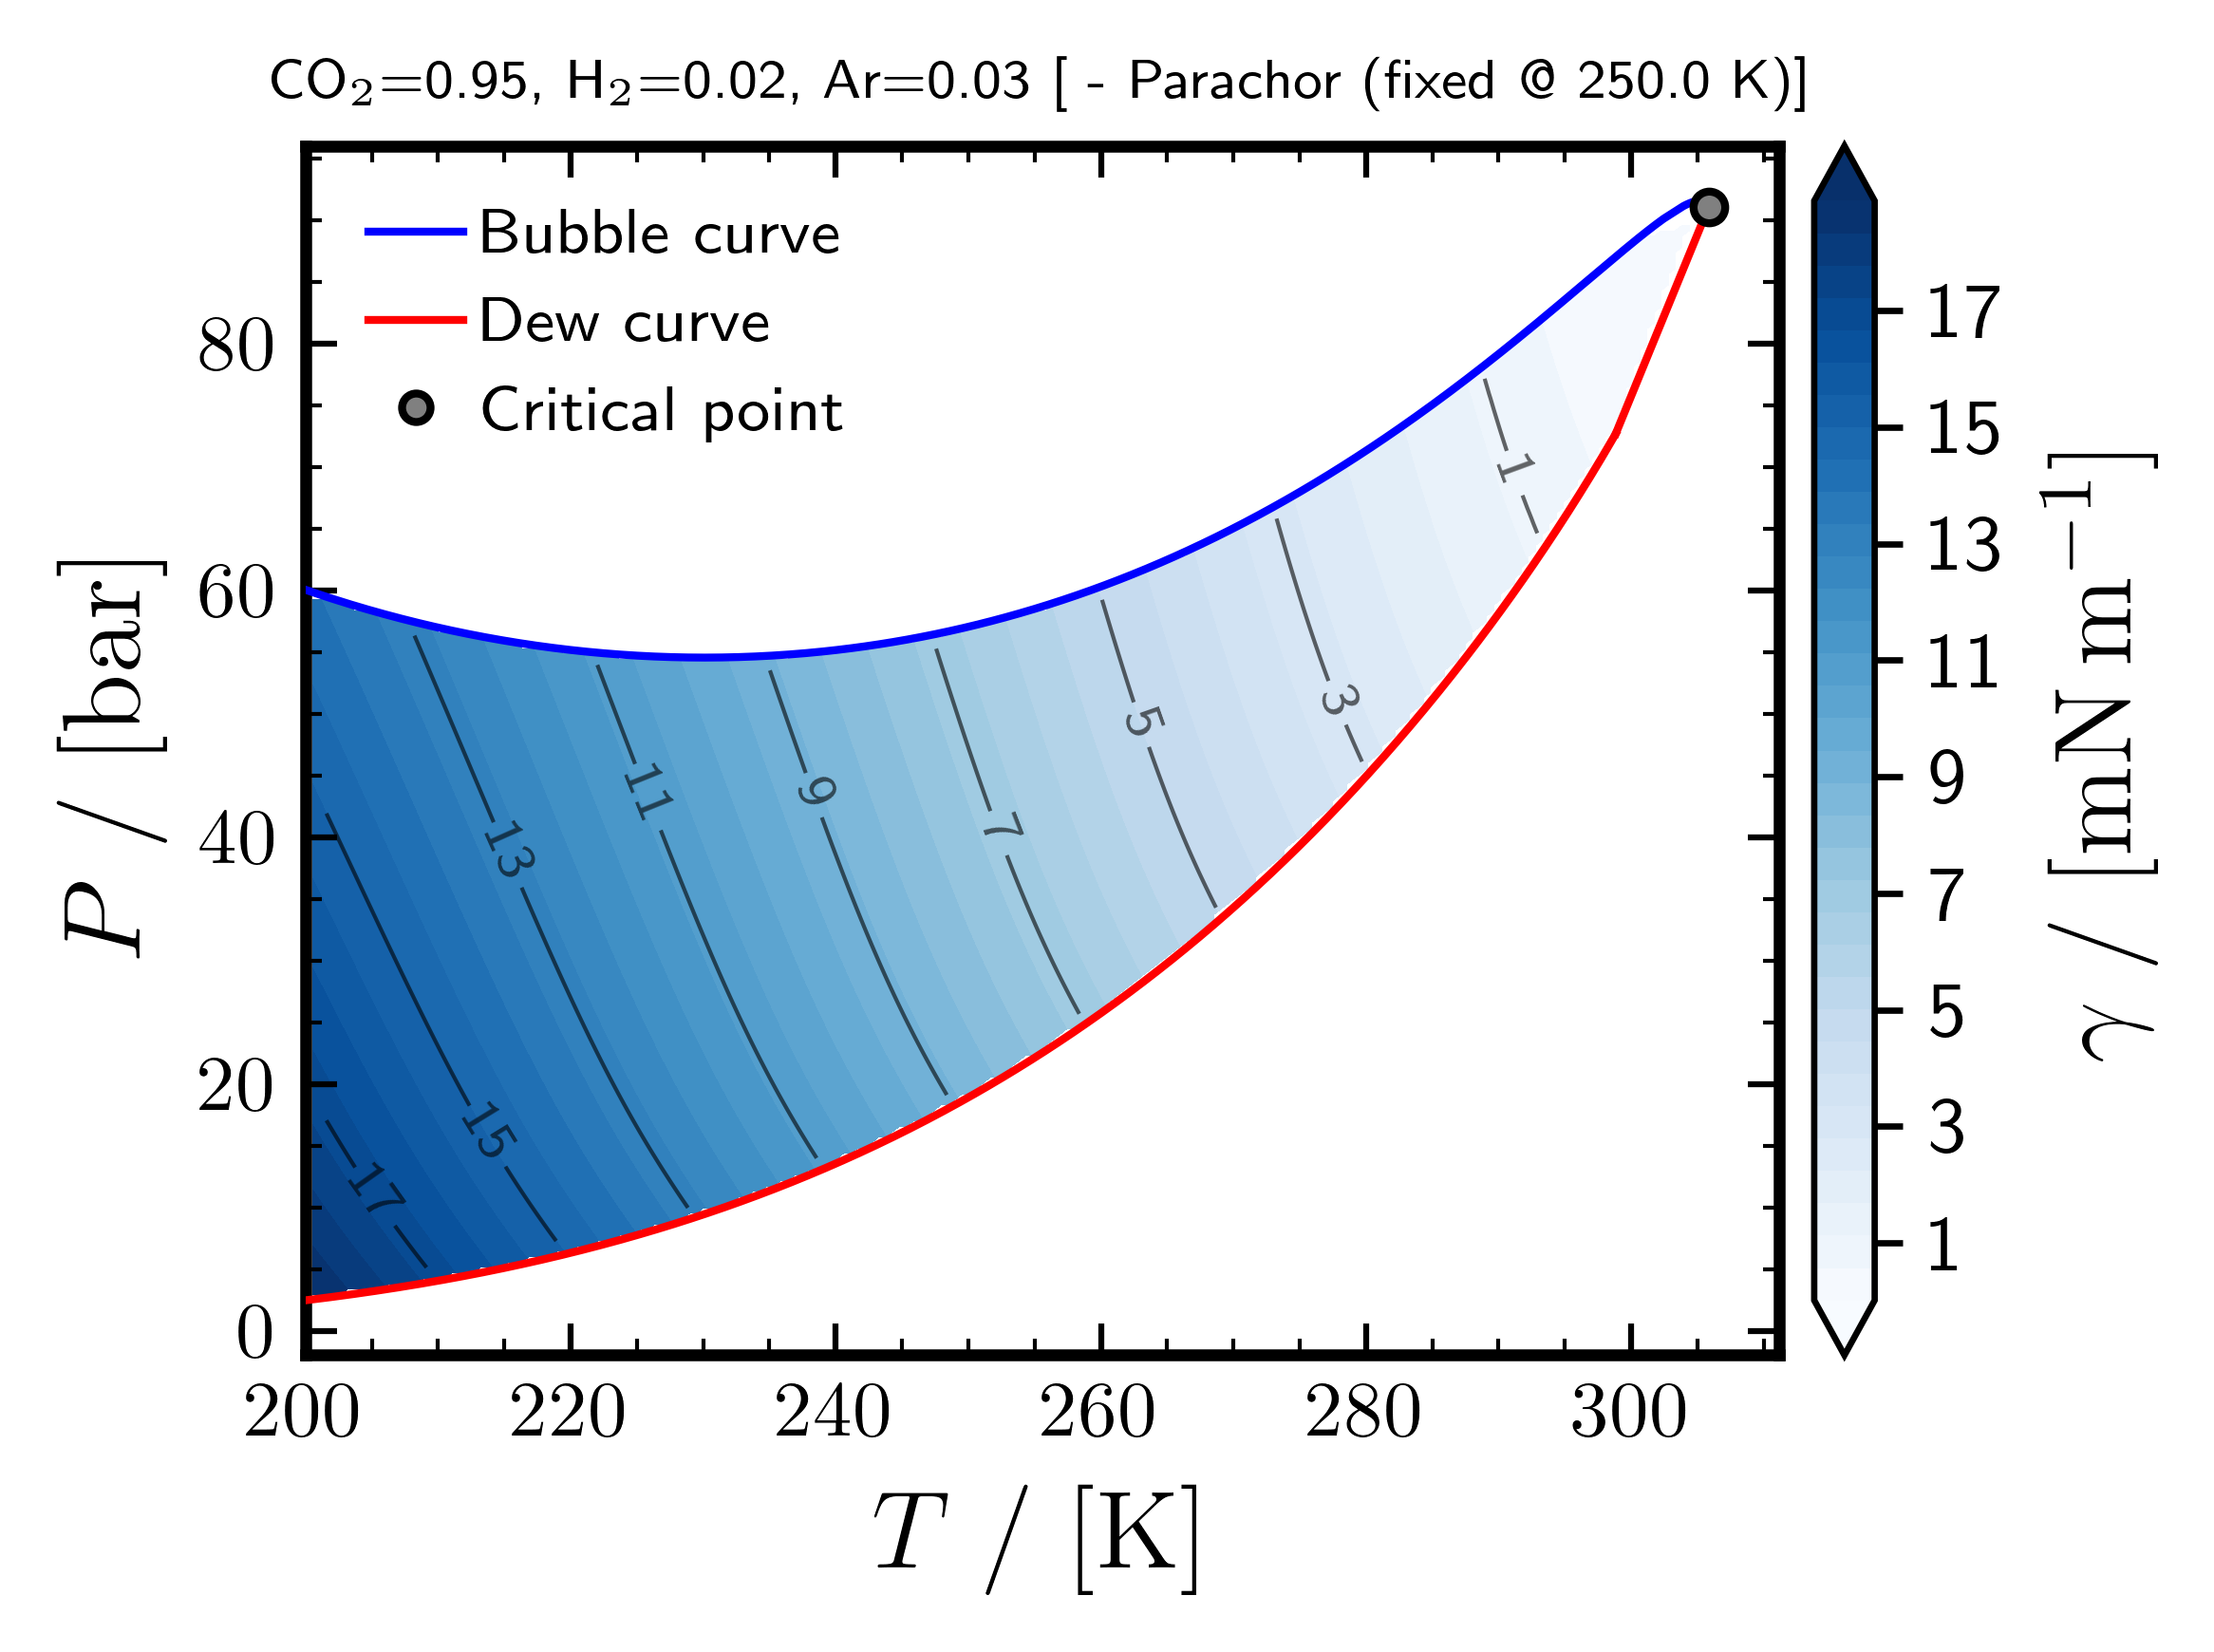

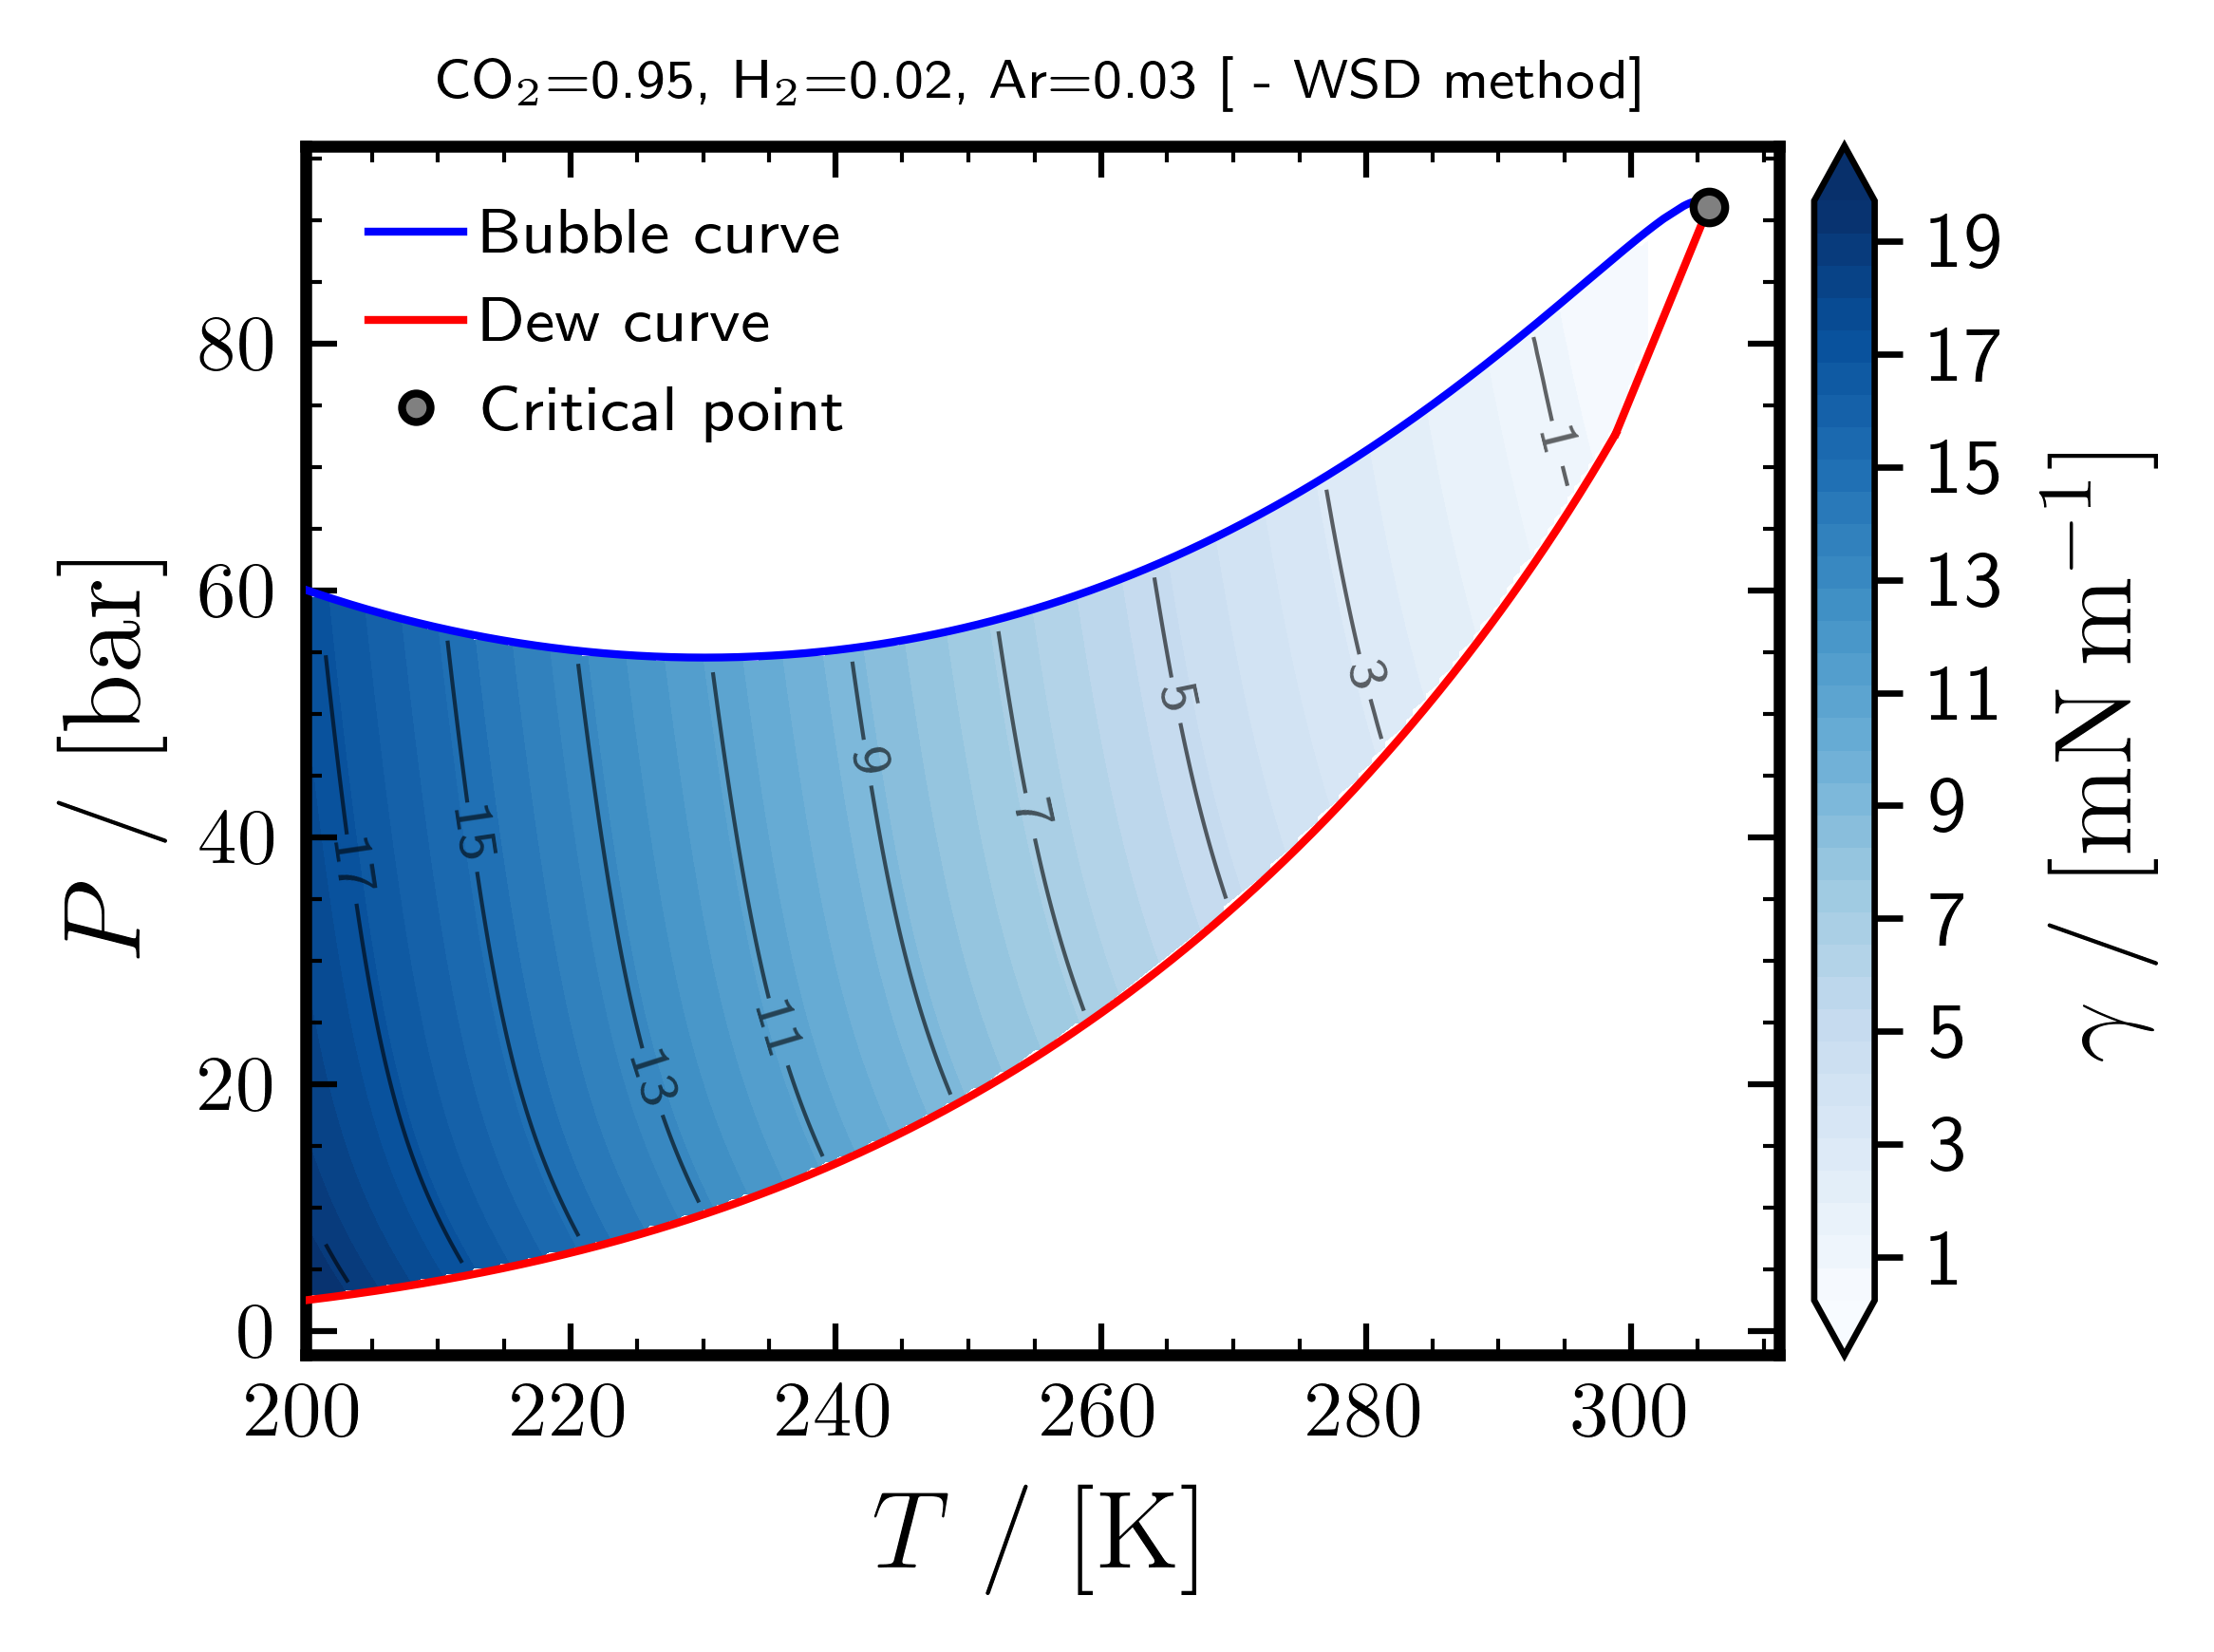

In [6]:
# -----------------------------------------
# Plots
# -----------------------------------------

# Parachor (T-dependent)
fig1, ax1 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_parachor,
    T_bub=T_bub, P_bub=P_bub, T_dew=T_dew, P_dew=P_dew,
    Tc_K=Tc_K, Pc_bar=Pc_bar, params=params, feed_z=FEED_Z,
    title_suffix=" - Parachor (T-dependent)")
plt.show()

# Parachor (fixed)
fig2, ax2 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_parachor_fixed,
    T_bub=T_bub, P_bub=P_bub, T_dew=T_dew, P_dew=P_dew,
    Tc_K=Tc_K, Pc_bar=Pc_bar, params=params, feed_z=FEED_Z,
    title_suffix=f" - Parachor (fixed @ {T_ref} K)")
plt.show()

# WSD
fig3, ax3 = SEC.semi_emperical_correlations.plot_PT_colormap(
    data=data_wsd,
    T_bub=T_bub, P_bub=P_bub, T_dew=T_dew, P_dew=P_dew,
    Tc_K=Tc_K, Pc_bar=Pc_bar, params=params, feed_z=FEED_Z,
    title_suffix=" - WSD method")
plt.show()

In [7]:
# ---------------------------------------------------------------
# Save PT colormap DataFrames  (one CSV per method)
# ---------------------------------------------------------------
# Optional: define ALL_COMPONENTS for consistent column layout
# across different mixture runs (inactive cols are zero-padded).
# Set to None to use only the active COMPONENT_NAMES.
ALL_COMPONENTS = ["carbon dioxide", "hydrogen", "argon"]   # adjust / extend as needed

dfs_PT = SEC.semi_emperical_correlations.save_PT_colormap_dataframes(
    data_parachor       = data_parachor,          # T-dependent parachor
    data_wsd            = data_wsd,               # WSD method
    output_dir          = "CSV_PT_colormap",
    component_names     = COMPONENT_NAMES,
    feed_z              = FEED_Z,
    n_exp               = 3.87,
    ML_mode             = True,                   # full feature set for ML
    main_component_index= 0,                      # CO2 pure props kept; impurities often SC
    all_components      = ALL_COMPONENTS,
    data_parachor_fixed = data_parachor_fixed,    # fixed-T parachor (optional)
    T_ref_fixed         = T_ref,                  # only used for the print label
)

# Unpack
df_PT_para       = dfs_PT["PT_parachor"]
df_PT_para_fixed = dfs_PT["PT_parachor_fixed"]
df_PT_wsd        = dfs_PT["PT_wsd"]

print("\nParachor (T-dep) columns:",  list(df_PT_para.columns))
print("Parachor (fixed) columns:",    list(df_PT_para_fixed.columns))
print("WSD columns:",                 list(df_PT_wsd.columns))

Saved CSV_PT_colormap/PT_parachor.csv (869 rows, 30 cols)
Saved CSV_PT_colormap/PT_parachor_fixed.csv (869 rows, 30 cols) (T_ref=250.0 K)
Saved CSV_PT_colormap/PT_wsd.csv (832 rows, 26 cols)

Parachor (T-dep) columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', 'rhoV2_hydrogen', 'rhoV3_argon', 'gamma0_carbon dioxide', 'rhoL0_carbon dioxide', 'rhoV0_carbon dioxide', 'Tc_carbon dioxide', 'Pc_carbon dioxide', 'Psat0_carbon dioxide', 'parachor_carbon dioxide', 'parachor_hydrogen', 'parachor_argon', 'n_exp', 'gamma_parachor']
Parachor (fixed) columns: ['T', 'P', 'z_carbon dioxide', 'z_hydrogen', 'z_argon', 'rho_l', 'rho_v', 'x_carbon dioxide', 'x_hydrogen', 'x_argon', 'y_carbon dioxide', 'y_hydrogen', 'y_argon', 'rhoL1_carbon dioxide', 'rhoL2_hydrogen', 'rhoL3_argon', 'rhoV1_carbon dioxide', '

In [8]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.99 minutes
